## Add synthetic planet atmosphere spectrum in SPIRou data set

In [1]:
### Dependencies of the notebook
import numpy as np
import sys
import os
import time
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib
import pandas as pd
import copy
from src import *
from plots import *

font = {'size'   : 22,
        'weight': 'light'}
axes = {'labelsize': 22,
        'labelweight': 'light'}
matplotlib.rc('font', **font)
matplotlib.rc('axes', **axes)

## 0. Read data

This section aims at reading the input SPIRou observations and injecting a synthetic planet atmosphere spectrum therein. 
<font color='red'>A few notes:</font>
- The cell below contains the main parameters to read the data and compute a realistic planet template. 
- In this example, the planet properties are based on the hot Jupiter **HD 189733 b**. In order to inject a realistic planet signature in the data, we need to compute a so-called transit window given the fraction of the planet occulting the star. Usually, this is done by computing a transit curve (e.g., using the python [batman module](https://lweb.cfa.harvard.edu/~lkreidberg/batman/). Since the installation of the module can be quite tricky depending on the distribution of your laptop, we pre-computed a transit curve (see file **transit_flux.dat**). Note however that the function **compute_transit** (in **src.py**) can be uncommented and used for any input planet parameters. Since a transit curve is already computed, the following star/planets parameters are actually not used in the code: Rp, Rs, ap, ep, ip, wp, limb dark, uh. Note: a realistic estimate of the stellar limb-darkening coefficients can be found on [this website](https://vizier.u-strasbg.fr/viz-bin/VizieR-4).
- <font color='red'>Important note:</font> In this tutorial, SPIRou orders are designated by the absolute index. In other words, the reddest order is Order 31 whereas the bluest is Order 79. **Note that the mean wavelength corresponding to each order number can be found in the output of Section 1.1**.


In [4]:
# -----------------------------------------------------------------------
# GLOBAL PARAMETERS
pipeline_rep = "/home/florian/Bureau/Atmosphere_SPIRou/Pipeline_git/ATMOSPHERIX_DATA_RED/"
dir_data   = pipeline_rep+"Data_Simulator/Data/T_files_1"   ### Directory containing all 
orders     =  np.arange(31,80)[::-1].tolist() ### List of all orders analysed

In [5]:
### READ DATA - SUBTRACT BLAZE - REMOVE NaNs

print("Read data")
list_ord = []
nord     = len(orders)
for kk in range(nord):
    list_ord.append(Order(orders[kk])) ### Initialize list of Order objects
list_ord,airmass,T_obs,berv,snr_mat = read_data_spirou(dir_data,list_ord,nord)
nobs = len(T_obs)
print("DONE")

### Remove all NaNs and form array like structures
print("Remove NaNs")
cmp = 0
for mm in range(nord):
    O   = list_ord[cmp]   
    err = O.remove_nan()
    if err > 0: ### If only NaNs
        print("Order",O.number,"empty - removed")
        del orders[cmp]
        del list_ord[cmp]
    else: cmp += 1
nord = len(list_ord)
print("DONE")





Read data
DONE
Remove NaNs
DONE



Compute velocity correction - Geocentric to stellar rest frames 
DONE

Planet rad  = 0.5485294117647059 R_jup
Planet mass = 0.5715686274509804 M_jup
g = 49.235624176168415 m/s
ap =  14.053403029671816 Rs
Ks = 0.16387070936420686 km/s
Kp = 120.17981110166183 km/s
Transit duration: 1.4428030885756016 h


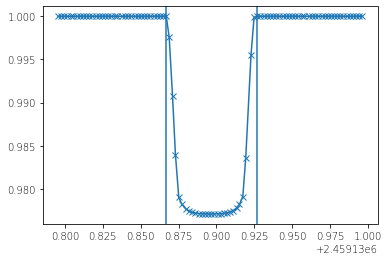

In [6]:

# -----------------------------------------------------------------------
# STELLAR / PLANET PARAMETERS
Ms        = 0.4*1.989*1e30                   # Stellar mass [kg]
T0        = 2459130.8962180                  #Mid-transit time [BJD]
Porb1     = 2.21857545                       #Planet orbital period [d]
V0        = 11.73                            #Stellar Systemic Vel [km/s]
G         = 6.67408e-11
Rs        = 261127.5                          #Stellar radius [km]
ep1       = 0.0                              #Orbital eccentricity
ip1       = 90                               #Orbital inclination [deg]
wp1       = 0.0                              #Argument of the periapsis [deg] 
limb_dark = "quadratic"                      #limb darkening model ("nonlinear", "quadratic", "linear")
uh        = [0.0156,0.313]                   #Values of limb-darkening coefficients
ap1       = ((Porb1*24.*3600)**(2)*G*Ms/(4.*np.pi**(2)))**(1/3)/(Rs*1e3)

### Constant parameters
Rp_hd189  =  1.119 * 69911.0 # km   - Addison+19
Mp_hd189  =  1.166 * 1.898e27 # kg   - Addison+19
Rs_hd189  =  0.765 * 696340. # Addison+19
Td_hd189  = Rp_hd189**(2) / Rs_hd189**(2)
T_hd189   = 900.0   ### Limb Temperature
g_hd189   = 6.6743e-11 * Mp_hd189 / ((Rp_hd189*1e3)**(2))

Rp_GJ436  =  0.26 * 69911.0  # km   - Addison+19
Mp_GJ436  =  0.036 * 1.898e27 # kg   - Addison+19
Rs_GJ436  =  0.375 * 696340. # Addison+19
Td_GJ436  = Rp_GJ436**(2) / Rs_GJ436**(2)
T_GJ436  = 670.0   ### Limb Temperature
g_GJ436   = 6.6743e-11 * Mp_GJ436 / ((Rp_GJ436*1e3)**(2))



### Derived parameters
Rp1       = np.sqrt(Td_hd189*Rs**(2))
g1        = g_hd189 * Rs_hd189 /(Rs)
Mp1       = g1*(Rp1*1e3)**(2)/(6.6743e-11)
Ks1       = ((2.*np.pi*G)/(Porb1*24*3600.))**(1./3)*Mp1*np.sin(np.pi*ip1/180.)/(Mp1+Ms)**(2./3)
Ks1      *= 1./np.sqrt(1-ep1**(2))/1000.
Kp1       = Ks1*Ms/Mp1


# Rp1       = np.sqrt(Td_GJ436*Rs**(2))
# g1        = g_GJ436 * Rs_GJ436 /(Rs)
# Mp1       = g1*(Rp1*1e3)**(2)/(6.6743e-11)
# Ks1       = ((2.*np.pi*G)/(Porb1*24*3600.))**(1./3)*Mp1*np.sin(np.pi*ip1/180.)/(Mp1+Ms)**(2./3)
# Ks1      *= 1./np.sqrt(1-ep1**(2))/1000.
# Kp1       = Ks1*Ms/Mp1


print("\nCompute velocity correction - Geocentric to stellar rest frames ")
Vp1     =   get_rvs(T_obs,Ks1,Porb1,T0)  #[km/s]
Vc1     =   V0 - berv + Vp1
print("DONE\n")

phase1  = (T_obs - T0)/Porb1
phase1 -= int(phase1[-1])  


print("Planet rad  =",Rp1/(69911),"R_jup")
print("Planet mass =",Mp1/(1.898e27),"M_jup")
print("g =",g1,"m/s")
print("ap = ",ap1,"Rs")
print("Ks =",Ks1,"km/s\nKp =",Kp1,"km/s")

flux1         = compute_transit(Rp1,Rs,ip1,T0,ap1,Porb1,ep1,wp1,limb_dark,uh,T_obs)
window1       = (1-flux1)/np.max(1-flux1)
n_ini1,n_end1 = get_transit_dates(flux1)



print("Transit duration:",24*(T_obs[n_end1]-T_obs[n_ini1]),"h")


plt.plot(T_obs,flux1,"-x")
plt.axvline(T_obs[n_ini1])
plt.axvline(T_obs[n_end1])
plt.show()


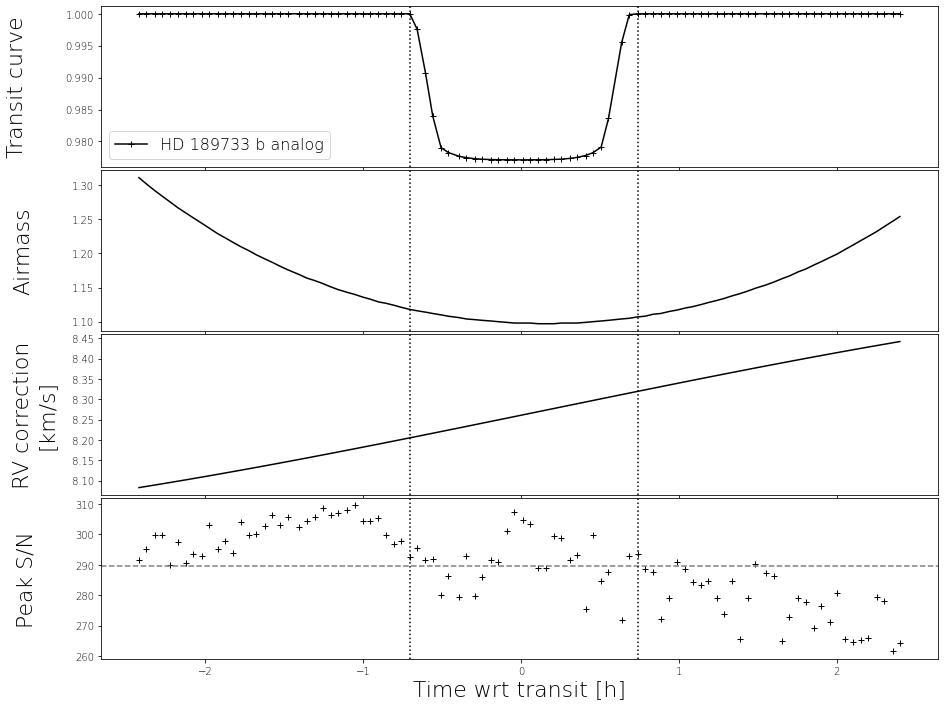

In [8]:
TT     = 24.*(T_obs - T0)


ypad   = 15  # pad of the y label

plt.figure(figsize=(15,12))

# Transit flux
ax  = plt.subplot(411)

ax.plot(TT,flux1,"-+k",label="HD 189733 b analog")
ax.axvline(TT[n_ini1],ls=":",color="k")
ax.axvline(TT[n_end1],ls=":",color="k")


# ax.axvline(TT[n_ini2],ls="--",color="g")
# ax.axvline(TT[n_end2],ls="--",color="g")
plt.legend(loc=3,fontsize=16)
# ax.set_xticks([])
ax.set_ylabel("Transit curve\n", labelpad=ypad)

# Airmass
ax = plt.subplot(412)
plt.plot(TT,airmass,"-k")
ax.axvline(TT[n_ini1],ls=":",color="k")
ax.axvline(TT[n_end1],ls=":",color="k")
# ax.axvline(TT[n_ini2],ls="--",color="g")
# ax.axvline(TT[n_end2],ls="--",color="g")
# plt.xticks([])
ax.set_ylabel("Airmass\n", labelpad=ypad)

# RV correction between Geocentric frame and stellar rest frame
ax = plt.subplot(413)
plt.plot(TT,Vc1,"-k")
ax.axvline(TT[n_ini1],ls=":",color="k")
ax.axvline(TT[n_end1],ls=":",color="k")
# ax.axvline(TT[n_ini2],ls="--",color="g")
# ax.axvline(TT[n_end2],ls="--",color="g")
# plt.xticks([])
ax.set_ylabel("RV correction\n[km/s]", labelpad=ypad)

# Maximum S/N
ax = plt.subplot(414)
plt.plot(TT,np.max(snr_mat,axis=1),"+k")
plt.axhline(np.mean(np.max(snr_mat,axis=1)),ls="--",color="gray")
ax.axvline(TT[n_ini1],ls=":",color="k")
ax.axvline(TT[n_end1],ls=":",color="k")
# ax.axvline(TT[n_ini2],ls="--",color="g")
# ax.axvline(TT[n_end2],ls="--",color="g")
plt.xlabel("Time wrt transit [h]")
ax.set_ylabel("Peak S/N\n", labelpad=ypad)

plt.subplots_adjust(hspace=0.02)
plt.savefig(pipeline_rep+"Figures/transit_info.pdf",bbox_inches="tight")
plt.show()

#### 1.3. Add synthetic planet signature 

We now add a synthetic planet signature to the data. 

In [11]:
name_model1        = pipeline_rep+"Data_Simulator/Model/Results/RpGL15A_HD189_onlyH2O-VMR3-T900.txt" 
name_wave1         = pipeline_rep+"Data_Simulator/Model/Results/lambdasGL15A_HD189_onlyH2O-VMR3-T900.txt" 

W_mod1,I_mod1      = np.loadtxt(name_wave1),np.loadtxt(name_model1)
T_depth1           = (I_mod1/(1e5))**(2) / Rs**(2)
Td1                = (T_depth1 - T_depth1.mean())+ T_depth1.mean()


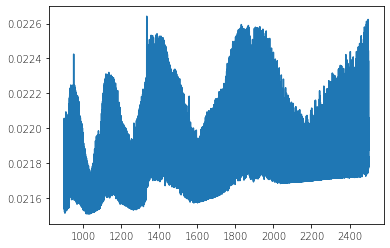

In [12]:
plt.plot(W_mod1,Td1)

Select the semi-amplitude K_inj of the RV of the injected planet signature and the RV at mid-transit, V_inj. K_inj can be obtained from the star planet mass ratio (q = Ms/Mp) and the semi-amplitude of the RV signature induced by the planet of the host star, Ks, such that: **K_inj = q * Ks**. V_inj is expected to be close to 0 (non-zero values are interpreted as the presence of stellar winds towards or away from the observer). 

In [22]:
###  Inject the planet signature into the data
K_inj1      = Kp1     ### Semi-amplitude of the injected planet RV (Jupiter)
V_inj1      = 30.0    ### RV at mid-transit of the injected planet
Vc          = Vc1
ampl        = 1.0  ### Amplification factor to boost the injected planet signal
numb        = 47      ### Select here the order for which you want to plot the synthetic planet signature
discard     = np.zeros(nord)
list_ord_pl = copy.deepcopy(list_ord) # Independent copy of the list of Order objects

for nn in range(nord):

    O          = list_ord_pl[nn]
    Wmin,Wmax  = 0.95*O.W_raw.min(),1.05*O.W_raw.max() # Take a wavelength range +/-5% larger than data
    indm1      = np.where((W_mod1>Wmin)&(W_mod1<Wmax))[0]
    W_sel1     = W_mod1[indm1]
    I_sel1     = Td1[indm1]  
    if np.min(W_sel1) > 0.995*np.min(O.W_raw) or np.max(W_sel1) < 1.005*np.max(O.W_raw):
        print("Order",O.number,"incomplete -- discarded")
        discard[nn] = 1
    else:
        Ip1 = O.add_planet(W_sel1,I_sel1,window1,phase1,K_inj1,V_inj1,Vc,ampl)
        O.I_raw_jup = Ip1
    


Order 31 incomplete -- discarded


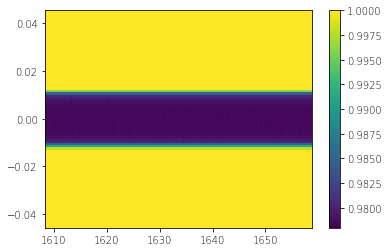

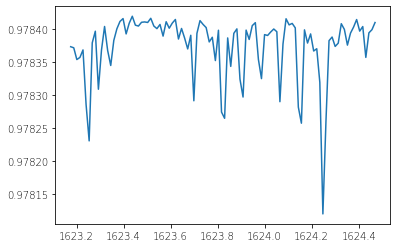

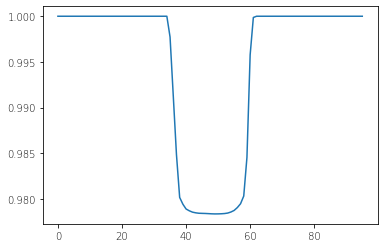

In [23]:
numb = 47

oo   = int(np.argmin(np.abs(np.array(orders,dtype=float)-numb)))
O    = list_ord_pl[oo]
X,Y  = np.meshgrid(O.W_raw,phase1)

plt.pcolor(X,Y,O.I_syn)
plt.colorbar()
plt.show()

plt.plot(O.W_raw[1100:1200],O.I_syn[47,1100:1200])
plt.show()


In [30]:
### Save simulated data
import pickle

orders_save=[]
Ir  = []
Ia  = []
Bl  = []
Ip = []
WW  = []
SN  = []

ind_rem = []

for nn in range(nord):
    if discard[nn]:
        print(nn)
        ind_rem.append(nn)
        continue
    O  = list_ord_pl[nn]
    
    onlynoise = np.zeros(O.I_raw.shape)
    
    #if you wnt just noise with the blaze and no star
    for i in range(len(onlynoise)):
        onlynoise[i] = np.random.normal(scale=10/O.SNR[i],size=np.shape(onlynoise)[1])
    onlynoise = 1+(onlynoise)*np.max(np.sqrt(O.B_raw))/np.sqrt(O.B_raw)
    
    O.I_noise = onlynoise
    orders_save.append(O.number)
    WW.append(O.W_raw)
    Ir.append(O.I_raw)
    Ia.append(O.I_atm)
    Bl.append(O.B_raw)
    #change Ip1 if you wnat no star and just noise
#     Ip.append(O.I_noise*O.I_syn)
    Ip.append(O.I_syn*O.I_raw)
    SN.append(O.SNR)
    

synthetic_file = pipeline_rep+'Simu_GL15A_HD189_Kp120_v30_onlyH2O-VMR3-T900.pkl'
savedata = (orders_save,WW,Ip,Bl,Ia,T_obs,phase1,window1,berv,V0+Vp1,airmass,SN)#,W_mod1,T_depth1,K_inj1,V_inj1)
with open(synthetic_file, 'wb') as ccfile:
    pickle.dump(savedata,ccfile)
    


48


In [ ]:
list_ord_pl = np.delete(list_ord_pl,ind_rem)

# 1. Data reduction

#### 1.1. Exclude strong telluric contamination and discard orders not covered by template

We start by removing regions located within strong telluric absorption lines following the method introduced in [Boucher et al. 2021](https://ui.adsabs.harvard.edu/abs/2021arXiv210808390B/abstract). From the median DRS-provided Earth atmosphere spectrum, we flag all telluric lines with a relative absorption larger than dep_min (conservative value of 40% in [Boucher et al. 2021](https://ui.adsabs.harvard.edu/abs/2021arXiv210808390B/abstract) and set to 50%). We then remove points on both sides of each flagged absorption line until reaching a relative level of 1-thres_up with respect to the continuum. Orders with less than Npt_lim points remaining after the telluric exclusion are discarded from the analysis (typically ~6 orders with water absorption bands -- orders 55-57 and 40-42). 


**NOTE:** We provide here the list of **all SPIRou orders** and their associated mean wavelength. 

List of the orders selected for the analysis:
   Order W_mean [nm] Nb pts Nb pts removed     Status
0     79         974   2636            226         ok
1     78         986   2611             49         ok
2     77         998   2681              0         ok
3     76        1012   2798              0         ok
4     75        1025   2911              0         ok
5     74        1039   2970              0         ok
6     73        1053   3020              0         ok
7     72        1067   2863              0         ok
8     71        1082   2869             10         ok
9     70        1098   2934             93         ok
10    69        1113   2644            908         ok
11    68        1131   2551           1305         ok
12    67        1147   2786           1160         ok
13    66        1165   2991            407         ok
14    65        1183   3408            221         ok
15    64        1202   3359            155         ok
16    63        1221   3513         

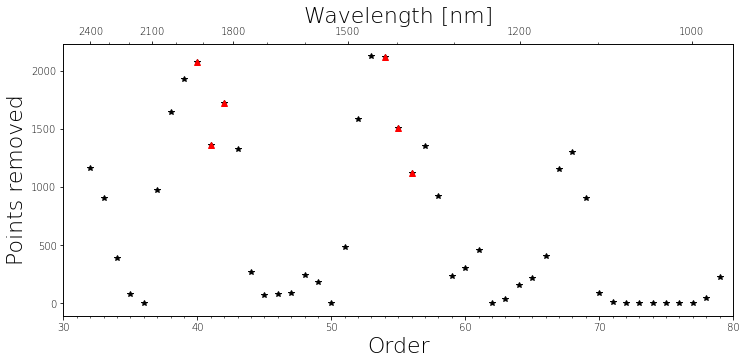

In [14]:
dep_min  = 0.3
thres_up = 0.05
### Remove regions of strong telluric absorption using Boucher et al. 2021 method
for nn in range(nord):
    list_ord_pl[nn].remove_tellurics(dep_min,thres_up)
  
    
### Remove all orders with less then Npt_lim pts remaining
### and display infos
Npt_lim = 500
npt_rem = np.arange(nord)
npt_ini = np.arange(nord)
ind_rem = []
ord_sta = ["ok" for i in range(nord)]
wmean   = np.arange(nord)

for nn in range(nord):
    O           = list_ord_pl[nn]
    
    npt_ini[nn] = len(O.W_raw)   
    npt_rem[nn] = len(O.W_raw) - len(O.W_cl)
    wmean[nn]   = O.W_mean    
    if discard[nn]>0:
        ind_rem.append(nn)
        ord_sta[nn] = "NOT COVERED"
    elif len(O.W_cl) <= Npt_lim:
        ind_rem.append(nn)
        ord_sta[nn] = "DISCARDED"        
list_ord_pl_fin =  np.delete(list_ord_pl,ind_rem)
nord_fin        = len(list_ord_pl_fin)
orders_fin      = np.delete(orders,ind_rem)
        
### Display results
infos = np.array([orders,wmean,npt_ini,npt_rem,ord_sta]).T
col   = ["Order","W_mean [nm]","Nb pts","Nb pts removed","Status"]
dtf   = pd.DataFrame(infos, columns=col)
print("List of the orders selected for the analysis:")
print(dtf)

### Display results
plot_orders(npt_rem,wmean,orders,ind_rem,laby="Points removed")

#### 1.2. Align spectra in the stellar rest frame

The data reduction procedure works with stellar spectra in the stellar rest frame. As the data are corrected for most of the telluric contamination (**t.fits** files), the spectra are dominated by the stellar contribution. As a consequence, working in the stellar rest frame allows us to remove the stellar contribution in a more efficient way than in the Geocentric frame (as the position of each stellar spectrum depends on the BERV). Note also that, when working with SPIRou e2ds files (or e.fits extensions), we may consider to do the data reduction process in the Geocentric frame. In this case, this will allow us to (i) remove more efficiently the telluric lines (aligned in the Geocentric frame) and (ii) avoid interpolating the observed spectra (no interpolation error added to the data).


We move the observed sequence of spectra from the Geocentric frame to the stellar rest frame, we process as follows:
- We interpolate each spectrum using scipy interp1d function (choose the type of interpolation by changing the parameter called "type"). 
- We shift the spectrum according to the velocimetric solution Vc computed in Section 0.1. Each value of the shifted spectrum is taken by intergrating the interpolation over one SPIRou pixel. 
- To avoid any extrapolation error, we remove the first and last **n_bor** points of each spectrum (note that, due to the blaze grating's structure, these points lie in regions of much higher noise level anyway).

In [15]:
frame    = "stellar"  ### "stellar" / "barycentric" vs "earth" / "geocentric"
n_bor    = 30
kind     = "linear"    ### "cubic" or "linear" --> see scipy interp1d page
print("\nInterpolate and align all spectra")
if frame == "stellar" or "barycentric":
    for nn in range(nord_fin):
        list_ord_pl_fin[nn].align(Vc,kind,n_bor)
print("DONE\n")


Interpolate and align all spectra
DONE



#### 1.3. Remove reference spectrum

The first step of the data reduction process consists in computing a high-S/N planet-free spectrum and remove it from each observed spectrum. In the stellar rest frame, the position of the stellar lines is constant (to the first order) during the observed sequence. In contrast, the position of the planet atmosphere lines is shifted by several km/s (several pixels) during the transit. As a consequence, the median observed spectrum should enclose most of the star contribution along with a negligible planet atmosphere contribution. To ensure that no planet atmosphere spectrum is enclosed in the median spectrum (especially when the RV semi amplitude of the planet is relatively low, e.g., for close-in planets less massive than Neptune), one option is to compute the median spectrum using only the out-of-transit spectra, but one has to ensure to have enough spectra in the baseline, in order to maximise the S/N of the reference spectrum.

In practice, we give the user the ability to select if the median spectrum is computed on all observations (**mode**="full") or on the out-of-transit spectra only (**mode**="out"). Once the median spectrum I_med is computed, we adjust I_med to each observed spectrum using a simple Least-squared estimator and divide the observed spectrum by the best-fitting prediction. We propose below to visualise the best-fitting solution for a given order (parameter **numb**).

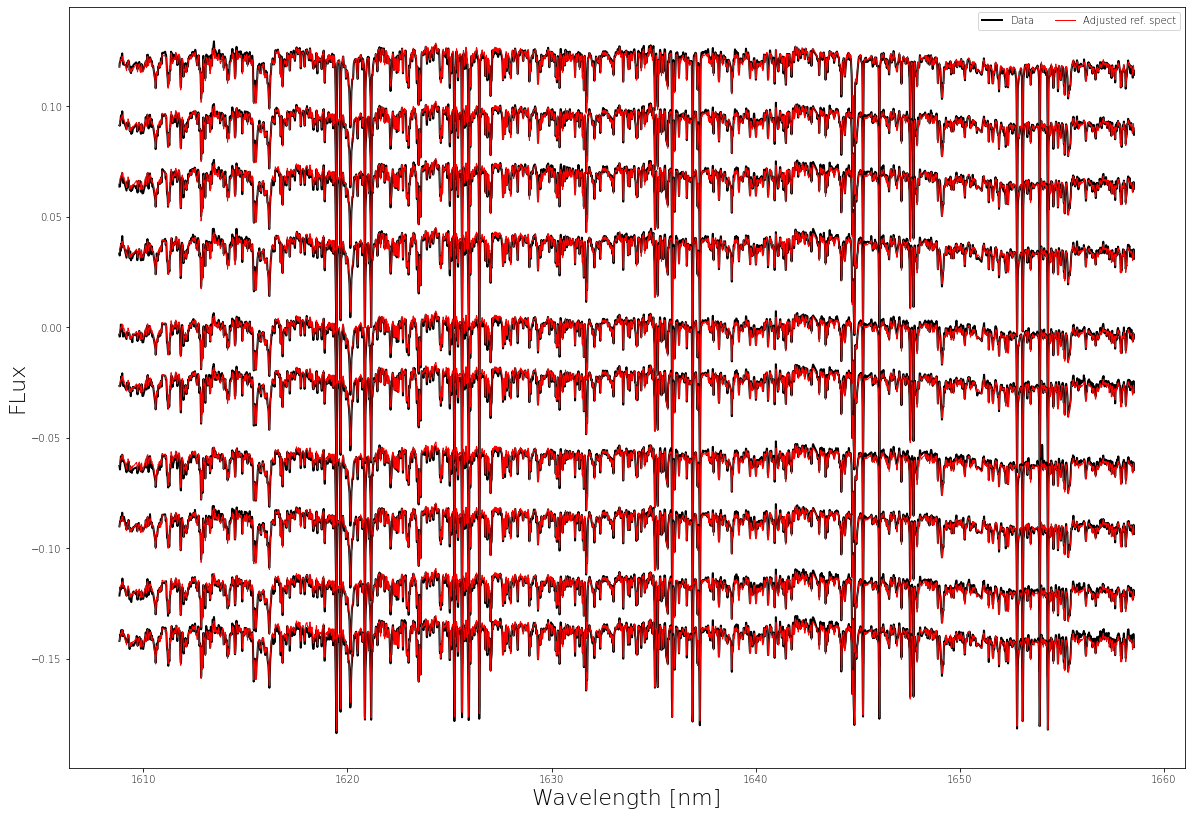

In [16]:
mode        = "out"  ### Compute median spec on "full" or "out"-of transit spectra
numb        = 47      ### Order for which we plot the prediction
oo          = int(np.argmin(np.abs(np.array(orders_fin,dtype=float)-numb)))

for kk in range(nord_fin):
    if kk == oo:
        list_ord_pl_fin[kk].subtract_stellar(mode,n_ini1,n_end1,True)        
    else:
        list_ord_pl_fin[kk].subtract_stellar(mode,n_ini1,n_end1,False)
        

#         lab   = ["Wavelength","Orbital phase","Flux"]
#         cmap  = "gist_heat"
#         title = "Raw data - order " + str(list_ord_fin[kk].number)
#         size  = (10,7)
#         plot_2D(list_ord[oo].W_al,phase,list_ord[oo].I_sub,lab,cmap,n_ini,n_end,title,size)

#### 1.4. Normalize the residual spectra

The resulting time series of spectra still exhibit low-frequencies structures due to correlated noise during the sequence (e.g., modal noise). Correcting for these trend as well as homogeneising the level of flux in each spectrum is a mandatory step in the correlation analysis. 

For each spectrum of each order, we perform the following iterative process:
- We apply a median filter (moving-median)
- Divide the spectrum by the moving median
- Conduct a sigma clipping to identify outliers
- For each flagged outlier, we remove a few adjacent points to correct for any potential pixel contamination
- We repeat the process until no outlier is identified

**WARNING:** This process typically takes a few min to run on all orders

**NOTE:** *There is no robust rule to tune the median filter here. Tests with synthetic data have shown that the results were marginally-impacted by variations of ~100 in N_med, as long as N_med is not too low or too large. One method to tune N_med for a given spectrum, would be to monitor the evolution of the dispersion of this spectrum normalized by the median filter for a range of N_med values. As N_med decreases (starting for abritrarily large values), the dispersion of the normalized spectrum will first decrease (correction of the low-frequency trends), reach a plateau, and decrease again (fit for white noise).*


Normalize residual spectra and remove outliers
Order n. 1 / 42
Order n. 11 / 42
Order n. 21 / 42


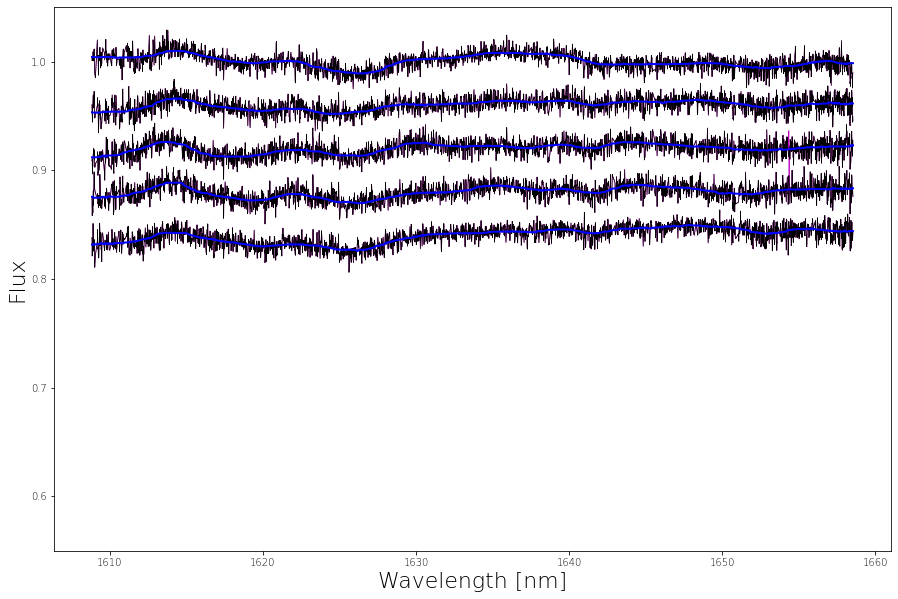

Order n. 31 / 42
Order n. 41 / 42
DONE

Duration: 0.9410406390825907 min


In [17]:
N_med   = 200   # Number of points for the median filter
sig_out = 5     # Threshold for the sigma clipping [in sigma]
N_adj   = 2     # Number of adjacent points removed for each outlier identified 
numb    = 47    # Index of the order displayed
N_bor   = 30    # Number of points removed at each side of eahc order
oo      = int(np.argmin(np.abs(np.array(orders_fin,dtype=float)-numb)))
time0   = time.time()

print("\nNormalize residual spectra and remove outliers")
for kk in range(nord_fin):
    if kk != oo: plot = False
    else: plot = True
    if kk%10==0.0: print("Order n.",kk+1,"/",nord_fin)
    list_ord_pl_fin[kk].normalize(N_med,sig_out,N_adj,N_bor,plot)

    
    
print("DONE\n")
time1 = time.time()
print("Duration:",(time1-time0)/60.,"min")



In [18]:
# O           = list_ord_pl_fin[oo]
# Is          = O.I_sub
# Ws          = O.W_al
# nbor        = N_bor
# N_med       = 100

# ind_out_fin = []
# I_norm      = np.zeros((len(O.I_sub),len(O.W_al)-int(2*nbor)))
# I_corr      = np.zeros(O.I_sub.shape)
# I_med_tot   = np.zeros(O.I_sub.shape)

# for nn in range(len(Is)):
#     I           = np.copy(Is[nn]) # Temp. spectrum
#     W           = np.copy(Ws)
#     out         = True  ## Is there outlier?
#     ind_out     = []

#     while out == True:

#         #### Apply median filter
#         I_med = median_filter(I,N_med)       # Median filter
#         In    = I/I_med                      # Normalize temp. spectrum
#         S     = sigma_clip(In,sigma=sig_out) # Identify outlier 
#         indo  = np.where(S.mask)[0]          # Spot outlier locations

#         ### Remove points adjacent to identified outlier on both sides of each identified outlier
#         ind = []
#         for jj in indo:
#             if jj-N_adj < 0: ini = 0
#             else: ini = jj-N_adj
#             if jj + N_adj + 1 > len(W): end = len(W)
#             else: end = jj + N_adj +1
#             ll = np.arange(ini,end)
#             ind.append(ll)
#         if len(ind) > 0:
#             ind_out.append(np.unique(np.concatenate(ind)))
#             I = np.delete(I,np.unique(np.concatenate(ind)))
#             W = np.delete(W,np.unique(np.concatenate(ind)))
#         else: out = False

#     ### Interpolate over outliers and apply median filter
#     f               = interp1d(W,I,"linear",fill_value="extrapolate")
#     If              = f(Ws)
#     Im              = median_filter(If,N_med)
#     In              = If/Im
#     I_norm[nn] = In[nbor:-nbor] # Remove pts at both edge of the order


#     I_corr[nn]    = If
#     I_med_tot[nn] = Im
# W_norm = O.W_al[nbor:-nbor]  


# plt.figure(figsize=(25,8))
# eps=0.05
# for nn in range(6):
#     plt.plot(Ws,Is[nn]-eps*nn,"-r",lw=0.7)
#     plt.plot(Ws,I_corr[nn]-eps*nn,"-k",lw=0.7)                
#     plt.plot(Ws,I_med_tot[nn]-eps*nn,"-m",lw=2.0)
# plt.ylabel("Flux")
# plt.xlabel("Wavelength [nm]")
# plt.show()                


#### 1.5. Detrending with airmass

Time-dependent residuals of absorption lines are still observed on the normalized spectra (residuals of strong lines whose absorption vary with airmass). A physically-motivated approach to correct for this time-varying structures is to **detrend the sequence of normalized spectra with airmass** (see [Brogi et al. 2016](https://ui.adsabs.harvard.edu/abs/2016ApJ...817..106B/abstract) or [Brogi et al. 2018](https://ui.adsabs.harvard.edu/abs/2018A%26A...615A..16B/abstract)). Although several more or less complex methods to detrend with airmass exist in the literature (e.g., in log space), we present here a very simplistic method consisting in modelling each normalized spectrum, $I_{\rm{n}}(t)$, by

$I_{\rm{n}}(t)$ = $\boldsymbol{I_{0}}$ + $\boldsymbol{I_{1}}$ $A$ + $\boldsymbol{I_{2}}$ $A^{2}$

where $A(t)$ is the airmass value at time $t$. This linear problem can be analytically solved using a least-squares estimator. Note that, in practice, such a simple model is not expected to fully describe time-dependent residuals within the sequence of spectra. In particular, the water absorption from the Earth atmosphere depends on more complex parameters than the airmass (see [Brogi et al. 2018](https://ui.adsabs.harvard.edu/abs/2018A%26A...615A..16B/abstract)). One alternative method is to directly apply statistical methods like principal component analysis in order to remove most of correlated noise from the normalized spectra (see [de Kok et al. 2013](https://ui.adsabs.harvard.edu/abs/2013A%26A...554A..82D/abstract) and Section 1.7).

In [19]:
list_ord_pl_fin[29].W_mean

1634.5213475093262


Detrending with airmass


/home/florian/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/florian/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/florian/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:250: RuntimeWarning: invalid value encountered in true_divide
  ret = um.true_divide(


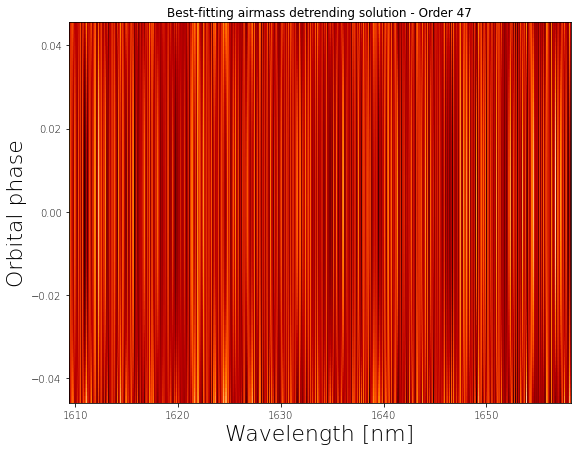

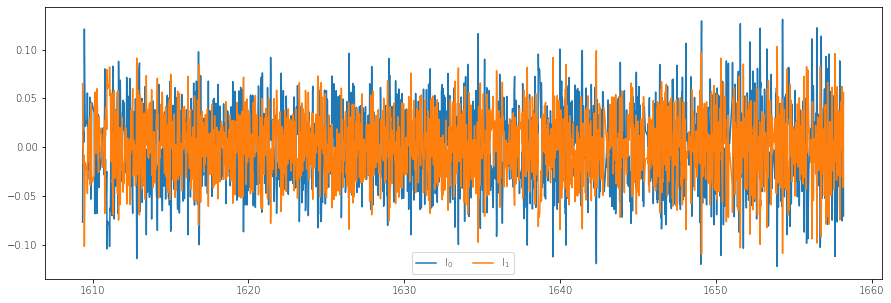

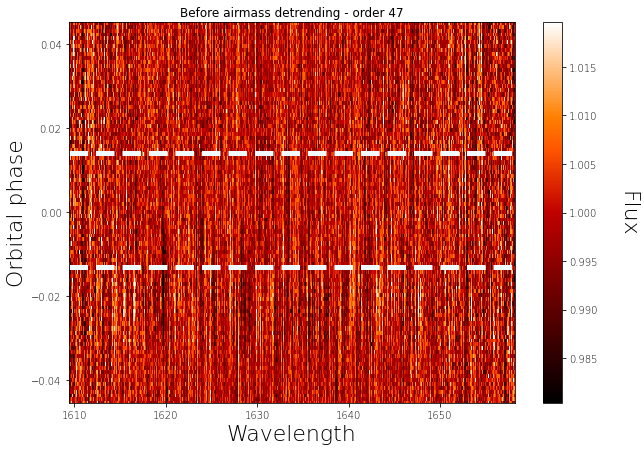

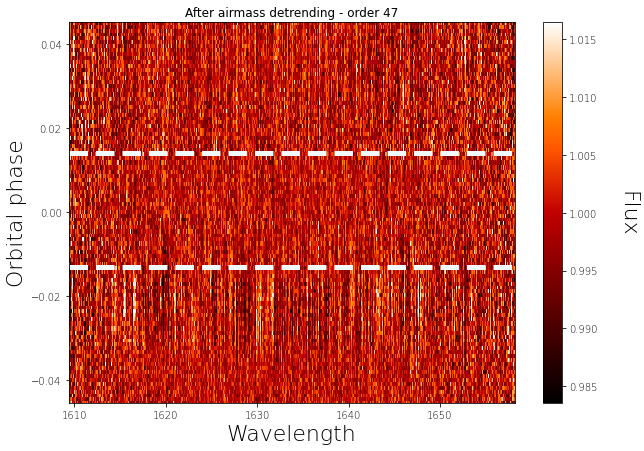

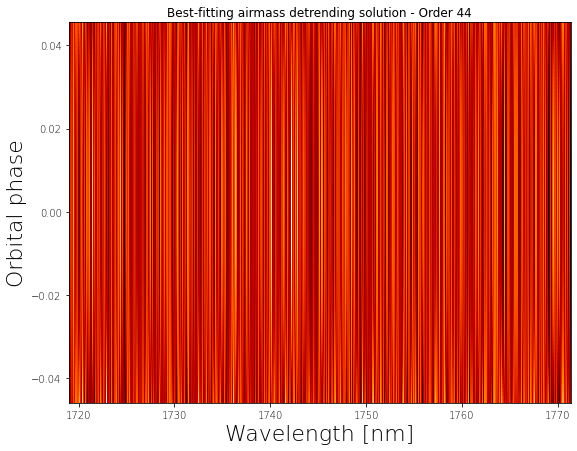

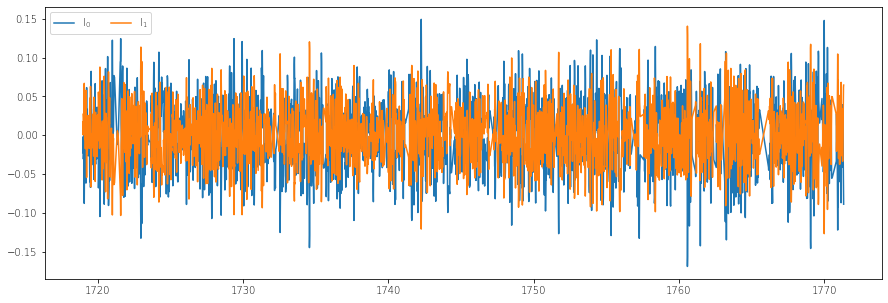

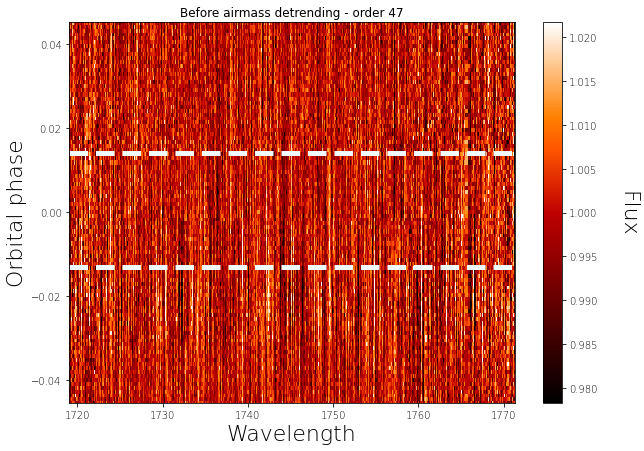

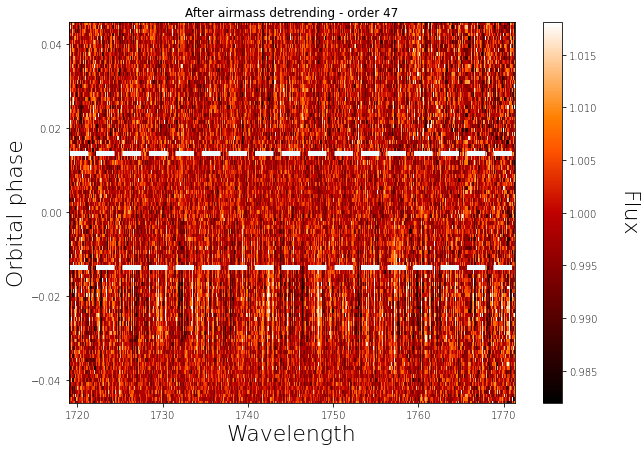

DONE



In [20]:
deg     = 1   ### Degree of the airmass model
numb    = 47  ### Plot best prediction for a given order
oo      = int(np.argmin(np.abs(np.array(orders_fin,dtype=float)-numb)))

print("\nDetrending with airmass")
for kk in range(nord_fin):
    pb, I_pred = list_ord_pl_fin[kk].detrend_airmass(airmass,deg)
    
    if kk == oo:
        O = list_ord_pl_fin[kk]
        plt.figure(figsize=(9,7))
        X,Y = np.meshgrid(O.W_norm,phase1)
        plt.pcolor(X,Y,I_pred,cmap="gist_heat")
        plt.xlabel("Wavelength [nm]")
        plt.ylabel("Orbital phase")
        title = "Best-fitting airmass detrending solution - Order " + str(O.number)
        plt.title(title)
        plt.show()
        
        plt.figure(figsize=(15,5))
        for nn,pp in enumerate(pb):
            lab = r"I$_{" + str(nn) + "}$" 
            plt.plot(O.W_norm,pp,label=lab)
        plt.legend(ncol=3)
        plt.show()
    
        lab   = ["Wavelength","Orbital phase","Flux"]
        cmap  = "gist_heat"
        oo    = int(np.argmin(np.abs(np.array(orders,dtype=float)-numb)))
        title = "Before airmass detrending - order " + str(list_ord[oo].number)
        size  = (10,7)
        plot_2D(O.W_norm,phase1,O.I_norm,lab,cmap,n_ini1,n_end1,title,size) 
        
        lab   = ["Wavelength","Orbital phase","Flux"]
        cmap  = "gist_heat"
        oo    = int(np.argmin(np.abs(np.array(orders,dtype=float)-numb)))
        title = "After airmass detrending - order " + str(list_ord[oo].number)
        size  = (10,7)
        plot_2D(O.W_norm,phase1,O.I_det,lab,cmap,n_ini1,n_end1,title,size)       



        
    
    
print("DONE\n")

#### 1.6. Filter bad pixels

In this step, we filter bad pixels (or velocity bins) in each order. We first compute the dispersion of each pixel (along the time axis). In principle, the sequence of spectra should be dominated by white noise by now and, therefore, each observation can be roughly seen as different realization of the photon/instrument noise (we encourage the user to double check this information by e.g., applying a Fourrier transform to the data). As a consequence, we expect the distribution of dispersions along the time axis in each order to shaped like a parabola with: (i) a minimum around the order center (level of dispersion corresponding to the DRS-provided S/N) and (ii) increasing noise at the order extremities (due to the blaze function). We therefore fit a parabola to the distribution of dispersions along the time axis using an iterative outlier removal procedure. All outliers removed in the process are flagged as bad pixels and discarded from the analysis.


Filter bad pixels
Order 79 : 21 pixel removed
[79.6914803  84.03967321 88.61003484 88.13246384 76.45275709 81.34698227
 80.83558298 81.83170335 83.12510645 88.15513302 85.46063823 82.98840485
 76.22570488 89.81637766 80.68401475 88.8973484  87.84736136 85.92001482
 93.22190767 86.30348057 82.45223866 87.16034182 87.19201764 97.31637135
 84.70406405 91.8412682  86.97962147 86.30764159 85.52991526 85.6766549
 84.62570011 87.77648551 86.97640742 82.73588986 82.39693422 78.59072153
 77.05634003 83.97458759 74.13319556 77.75003138 73.19258084 79.22464511
 73.49372506 78.54108571 83.83883462 83.80352656 86.89833789 93.8243271
 94.40899097 90.77272416 83.24372567 84.02780099 88.29497681 87.25364948
 84.98907169 81.39313566 74.33405584 87.23773994 77.19986257 81.0044222
 76.01709974 79.89345762 84.93220863 81.30749932 82.775715   75.45382456
 81.34441756 81.56371896 80.41615332 75.99280025 83.76015362 76.76022373
 74.12061219 72.65345018 80.38571554 73.80131836 78.54377694 85.15892952
 77.711

Order 69 : 7 pixel removed
[176.20333731 172.72039548 171.36447296 181.74694237 170.33671586
 179.48665615 166.87327496 168.13307795 164.35398939 167.6842817
 162.00391614 170.60670248 155.08792668 179.71020568 184.04137447
 167.13490952 166.18339918 179.66639293 159.42475381 166.34286707
 160.94513426 181.18298683 173.65418569 166.27240136 164.83750406
 164.53783999 176.47831005 161.40556932 175.13073181 166.06889043
 164.52418893 168.48693228 176.65310515 157.15795516 167.33021306
 165.64674051 153.33746597 168.07448081 164.3386835  159.11624567
 157.69970227 167.88959813 160.35797378 156.96914574 169.09319238
 158.20473062 177.23144702 179.06715253 174.62972476 167.64818198
 163.16684168 165.55812163 175.16900888 163.79175591 164.58919316
 169.44989382 162.83558166 160.6112103  151.30611237 173.09529857
 153.80365175 166.61986995 173.11149575 161.6120513  163.06286417
 154.29703339 156.41022893 164.87648093 156.63745537 160.35573795
 164.09528253 167.20597087 154.90533429 166.447980

[250.10240879 251.43431689 255.27718289 273.1056925  257.30474641
 274.72842072 257.26833451 278.37107737 258.92071822 253.43402374
 271.94478794 248.61859312 254.58298354 236.81899636 252.84645116
 243.2463521  234.08472279 217.55642521 203.24991651 208.40492304
 214.84850511 216.16733713 200.32656911 188.03683633 208.39947668
 222.68516862 195.30571975 187.55202719 210.39110823 219.97769995
 190.19949886 229.2287962  247.8801816  224.7640628  246.25764132
 250.07115041 211.23564671 234.24729789 229.0868985  232.74085951
 226.01187116 236.03437076 244.28231517 228.26350233 248.41766391
 253.49221232 255.33328534 244.63583404 264.80463351 251.89544969
 252.35542505 248.73450112 258.5123216  267.73374791 244.38553971
 252.14817321 254.62667029 247.70535283 253.85208874 253.80379841
 237.80918933 262.86132323 228.83242555 233.42705815 247.58641111
 220.48780213 227.40947492 247.44148956 227.5659422  235.32862489
 231.95936763 234.44775819 220.54602441 231.73800799 239.3490345
 211.002697

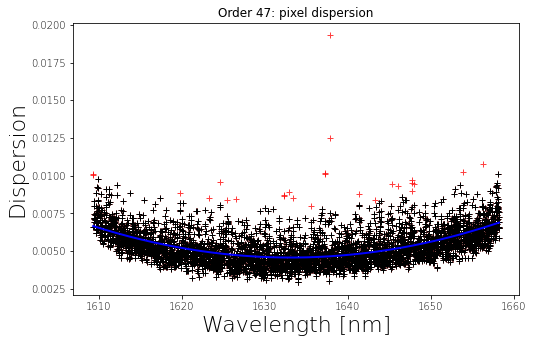

[231.0641277  247.55514816 254.00200733 251.29986778 269.13426054
 265.5703306  269.66014926 263.59905232 287.4084352  231.81049981
 279.60384529 243.93497077 243.606517   215.11560819 230.26558774
 219.84768694 196.14834702 184.06070194 173.41825955 173.6116274
 185.99848624 182.70638702 156.37861802 150.41463863 169.47475942
 173.7404096  146.82802026 156.76349891 179.50468672 155.39013006
 174.36592144 199.10423142 231.57543895 220.96209976 212.35028051
 227.26300635 203.09059371 228.74477759 221.75695387 209.71676651
 218.71198071 224.66651104 241.58858487 208.40335368 213.00027777
 225.65270725 233.88160133 209.33897879 239.1079108  236.25643406
 271.69465133 276.1002272  257.29834877 229.575781   253.16556512
 265.32454016 255.78415453 246.56707663 263.43318484 278.97058221
 243.07351323 224.47642455 203.89135184 203.35882358 214.6304563
 200.66477297 224.69413116 217.9425268  196.91913012 204.09065566
 194.12277739 211.3722321  204.66023345 203.86011421 193.30414448
 203.9207745

Order 33 : 18 pixel removed
[122.9062058  133.84959686 134.49572458 137.52655133 153.82927971
 162.04112749 173.07314011 151.35970815 145.676017   103.98831645
 148.76297109 123.93546854 138.19772957  96.38209587 114.40896957
 109.02971303  88.27222681  76.97023937  80.19537899  72.06537097
  89.31626941  85.92685997  68.97799897  70.44865717  84.40691151
  78.37228253  73.13446273  68.51920961  83.74139279  77.79588811
  76.18847671  89.3757777  101.05437528 102.32613393 101.16472368
 112.82303138 106.78375985 107.06438257 121.70099006 112.73780887
 116.00584485 111.66403425 142.93583959 102.52127762 114.54824877
 124.20305584 103.62425963  88.75250896 106.01319424  98.7000601
 127.39088655 138.27258661 115.06709728 112.27331585 122.89290377
 124.48566267 121.8465832  114.24849922 130.44357838 125.18291566
 114.96782593  99.49930144  88.03005596  87.60257904  89.48874169
  87.09778308  92.66035016  88.14500537  81.72968892  86.51305859
  90.87402742  83.71566517  92.44878643  92.23445

In [21]:
numb    = 47  ### Index of order displayed 
oo      = int(np.argmin(np.abs(np.array(orders_fin,dtype=float)-numb)))
deg_px  = 2   ### Degree of the polynomial fit
sig_px  = 4.0 ### Threshold for outlier removal [in sigma]
N_px    = 400 ### Size of window (in nb of points) centered on the order center, on which the empirical 
              ### spectrum S/N is computed
print("\nFilter bad pixels")
for kk in range(nord_fin):
    try:
        if kk == oo: list_ord_pl_fin[kk].filter_pixel(deg_px,sig_px,True)
        else: list_ord_pl_fin[kk].filter_pixel(deg_px,sig_px,False)
    except:
        continue
    list_ord_pl_fin[kk].get_pixel_dispersion(N_px)
print("DONE\n")

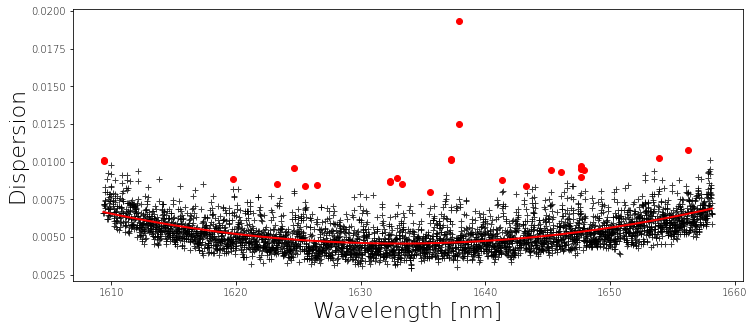

In [22]:
O             = list_ord_pl_fin[oo]
rms_px        = O.I_det.std(axis=0) # Dispersion of each pixel (computed along the time axis)
WW            = O.W_norm - np.mean(O.W_norm) # Wavelength vector for the fit
model,filt_px = poly_fit(WW,rms_px,deg_px,sig_px,10) ### See functions below
rms_pred      = model(WW) # Best prediction

### Identify and remove outliers
ind_px        = []
for ii in range(len(filt_px)):
    if filt_px[ii] != "--": ind_px.append(ii)
    elif rms_px[ii] < rms_pred[ii]: ind_px.append(ii)



plt.figure(figsize=(12,5))

for ii in range(len(O.W_norm)):
    if ii in ind_px:
        plt.plot(O.W_norm[ii],rms_px[ii],"+",color="k",alpha=0.75)
    else:
        plt.plot(O.W_norm[ii],rms_px[ii],"or")
plt.plot(O.W_norm,rms_pred,"r",lw=2.0)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Dispersion")
plt.show()

Here we compare the dispersion empirically-computed from the center of each order to the DRS-provided photon noise:

In [23]:
### Display global spectrum dispersion and compare it to DRS
plot_spectrum_dispersion(list_ord_pl_fin,"transit_dispersion.pdf")

/home/florian/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/florian/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/florian/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/florian/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/florian/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


#### 1.7. Filter correlated noise with Singular Value Decomposition

Although dominated by the white noise, the remaining sequence of spectra is still polluted by correlated noise (e.g., residuals of telluric/stellar spectra). If uncorrected, these components will harm the correlation process, with the result of masking or even mimicking a signature from the planet atmosphere. Hence the interest in using statistical methods, here, principal component analysis (PCA - in fact Singular Value Decomposition here) to remove a substantial fraction of the remaining correlated noise.

More information about PCA can be found one the (pretty well explained) [wikipedia page](https://en.wikipedia.org/wiki/Principal_component_analysis) and its application to a sequence of nIR spectra is described [here](https://ui.adsabs.harvard.edu/abs/2018arXiv180604617B/abstract) and [here](https://ui.adsabs.harvard.edu/abs/2019ApJ...878..153D/abstract). Let's consider our reduced sequence of spectra, $I_{\rm{red}}$, containing N$_{\rm{obs}}$ spectra and N$_{\rm{w}}$ wavelength bins. In the PCA framework, the sequence of spectra (in each order) is described as N$_{\rm{obs}}$ realizations of N$_{\rm{w}}$ random variables (centered and reduced beforehand). A PCA decomposition consists in projected the 2D matrix $I_{\rm{red}}$ onto an orthonormal basis $\mathcal{B}_{\rm{pca}}$ whose vectors are the eigenvectors of the covarance matrix associated to $I_{\rm{red}}$ and given by  $I_{\rm{red}}^{T} I_{\rm{red}}$. One can demonstrate that the larger the eigenvalue, the more the associated eigenvector (called PCA component) contributes to the variance budget of $I_{\rm{red}}$. As a consequence, if $I_{\rm{red}}$ is only drawn by uncorrelated noise, all eigen values will have the same order of magnitude. In contrast, correlated components will induce a discrepency in the distribution of eigenvalues. 

In practice, we use PCA to decompose $I_{\rm{red}}$ into its N$_{\rm{obs}}$ PCA components for each order and sort the eigenvalues (and associated eigenvectors) in decreasing order. We then chose the number of components associated to correlated noise (see next paragraph) and set them to 0, before projecting the PCA decomposition back into the original space. 

**Tuning the number of components to remove:** This step is critical in order to remove most of the residuals of telluric and stellar spectra while preserving the planet atmosphere contribution. Note that the amplitude of the planet atmosphere absorption lines is generally 10-100 times lower than the typical white noise level. From injection tests, we can easily demonstrate that the presence of the planet atmosphere spectrum has only a marginal effect on the distribution of eigenvalues in the PCA decomposition. In this tutorial, we compute the contribution $C$ of each eigenvector to the total variance budget (i.e., $C(e_{i}) = e_{i}/\Sigma_{j}e_{j}$, for all eigenvalue $e_{i}$). All eigenvalue $e_{i}$ for which $c(e_{i})$ is larger than a given user-provided threshold (set to 4% here) is said to be associated to correlated noise and the corresponding component is set to 0. A more robust way of tuning the number of removed components to remove by injecting a realistic planet atmosphere signal into the data and conduct the correlation analysis for different number of rejected components. But this method is model dependent. 




As a first step, you can visualize the first components associated to your favorite SPIRou order (select the order index with the parameter **numb** and the number of components displayed with **N_comp**). See the list of order indices and corresponding wavelengths in Section 1.1. You will noticed that the larger the component, the more complex the structures become (similar to taking the derivatives). 

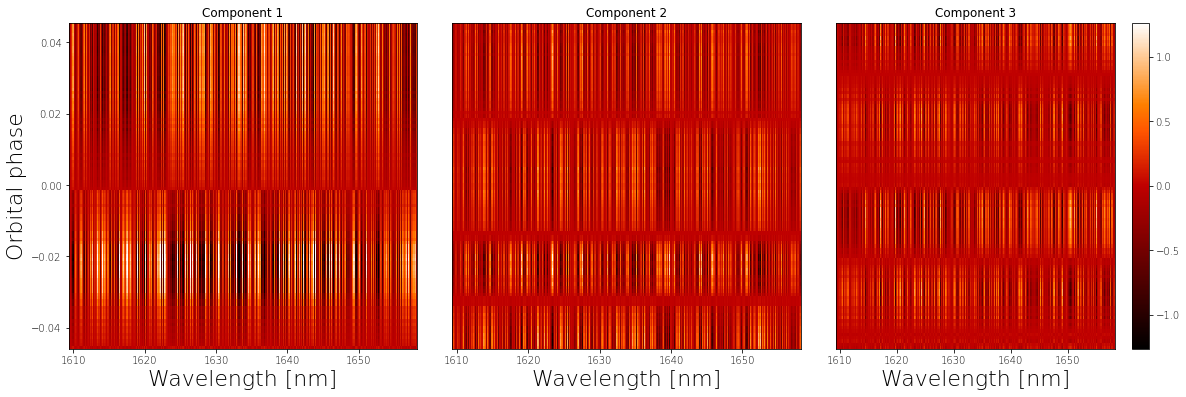

In [25]:
############# Plot the first components
### Note: This cell is just here to visualize PCA components

numb    = 47  ### Select index of order you want to display
oo      = int(np.argmin(np.abs(np.array(orders_fin,dtype=float)-numb)))
O       = list_ord_pl_fin[oo]
N_comp  = 3   ### Show the first N_comp components 
var,I_pca,I_del = make_pca(O.I_red,N_comp,True)
plt.figure(figsize=(20,6))
X,Y = np.meshgrid(O.W_red,phase1)
for nn in range(N_comp):
    ax = plt.subplot(1,N_comp,nn+1)
    vi = np.mean(I_del[0]) - 3.*np.std(I_del[0])
    vf = np.mean(I_del[0]) + 3.*np.std(I_del[0])
    cc = plt.pcolor(X,Y,I_del[nn],cmap="gist_heat",vmin=vi,vmax=vf)
    if nn > 0: plt.yticks([])
    if nn == 0: plt.ylabel("Orbital phase")
    if nn == N_comp-1:
        cb   = plt.colorbar(cc,ax=ax)
    title = "Component " + str(nn+1)
    plt.title(title)
    plt.xlabel("Wavelength [nm]")
plt.subplots_adjust(wspace=0.1)
plt.show()

**Main PCA process:** We know use the method described above to tune the number of components removed from the observed sequence of spectra for each order. Warning: this might take a few minutes to run. 

(96, 2269)
(96, 2427)
(96, 2554)
(96, 2657)
(96, 2771)
(96, 2830)
(96, 2888)
(96, 2709)
(96, 2720)
(96, 2697)
(96, 1609)
(96, 1120)
(96, 1489)
(96, 2440)
(96, 3033)
(96, 3065)
(96, 3332)
(96, 3301)
(96, 3011)
(96, 3044)
(96, 3262)
(96, 2537)
(96, 614)
(96, 1709)
(96, 3182)
(96, 3751)
(96, 3719)
(96, 3612)
(96, 3802)
(96, 3801)


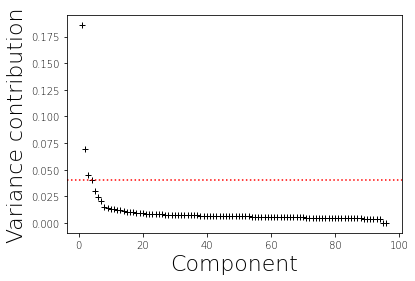

(96, 3817)
(96, 3616)
(96, 2079)
(96, 1681)
(96, 2667)
(96, 3905)
(96, 3815)
(96, 3546)
(96, 3008)
(96, 2549)


IndexError: index 40 is out of bounds for axis 0 with size 40

In [36]:
#### Automatic scaling of PCA
numb       = 47   ### Show the distribution of eigenvalues for this order
oo         = int(np.argmin(np.abs(np.array(orders_fin,dtype=float)-numb)))
threshold  = 0.04 ### threshold of variance contribution (above --> PCA components set to 0)
N_comp_fin = np.zeros(nord_fin,dtype=int)
wmean      = np.zeros(nord_fin)

ind2 = []
for nn in range(nord_fin):
    
    O_pl             = list_ord_pl_fin[nn]
    try:
        print(O_pl.I_red.shape)
        evar,I_pca       = make_pca(O_pl.I_red,0)
    except:
        ind_2.append(nn)
        continue

    indc             = np.where(evar>=threshold)[0]
    wmean[nn]        = O_pl.W_mean
    N_comp_fin[nn]   = len(indc)

    if nn == oo:
        XX = np.arange(len(evar)) + 1
        plt.figure(figsize=(6,4))
        plt.plot(XX,evar,"+k")
        plt.axhline(0.04,ls=":",color="r")
        plt.xlabel("Component")
        plt.ylabel("Variance contribution")
        plt.show()
        
    evar,I_pca   = make_pca(O_pl.I_red,N_comp_fin[nn])
    O_pl.I_pca   = I_pca
    
    
list_ord_pl_fin = np.delete(list_ord_pl_fin,ind2)
nord_fin -= len(ind2)

### Print number of components rejected for each order
infos = np.array([orders_fin,wmean,N_comp_fin]).T
col   = ["Order","W_mean [nm]","Components removed"]
dtf   = pd.DataFrame(infos,columns=col)
print(dtf)



In [37]:
orders_fin[23]

53

####  1.8. Summary -- Visualize all the data reduction process for a given order

Display the main steps of the data reduction process for a given order (change **numb** to change the order).

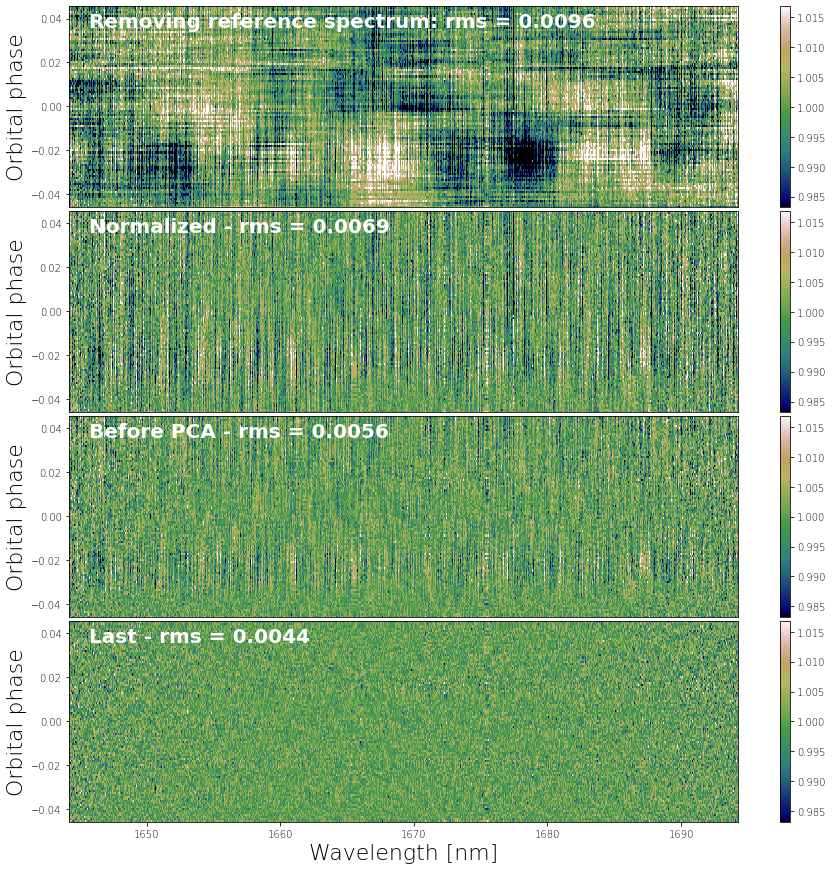

In [41]:
numb = 47  ### Show the evolution of the sequence of spectra for this order
O    = list_ord_pl_fin[int(np.argmin(np.abs(np.array(orders_fin,dtype=float)-numb)))]
cmap = "gist_earth" # Another fancy color map?

plt.figure(figsize=(15,15))

###############################        
ax   = plt.subplot(411)
X,Y  = np.meshgrid(O.W_al,phase1)
Z    = O.I_sub
zmin = O.I_red.mean() - 3.*O.I_red.std()
zmax = O.I_red.mean() + 3.*O.I_red.std()
c    = plt.pcolor(X,Y,Z,cmap=cmap,vmin=zmin,vmax=zmax) 
plt.colorbar(c,ax=ax)
ax.set_ylabel("Orbital phase")  
ax.set_xticks([])        
ax.set_xlim(np.min(O.W_red),np.max(O.W_red))

tx = "Removing reference spectrum: rms = " + str(round(np.std(Z),4))                           
plt.text(np.min(O.W_red)+1.5,0.8*np.max(phase1),tx,color="w",fontsize=20,fontweight="bold")

###############################  
ax   = plt.subplot(412)
X,Y  = np.meshgrid(O.W_norm,phase1)
Z    = O.I_norm
zmin = O.I_red.mean() - 3.*O.I_red.std()
zmax = O.I_red.mean() + 3.*O.I_red.std()
c    = plt.pcolor(X,Y,Z,cmap=cmap,vmin=zmin,vmax=zmax)   
ax.set_ylabel("Orbital phase")  
ax.set_xticks([])        
ax.set_xlim(np.min(O.W_red),np.max(O.W_red))
plt.colorbar(c,ax=ax)

tx = "Normalized - rms = " + str(round(np.std(Z),4))                            
plt.text(np.min(O.W_red)+1.5,0.8*np.max(phase1),tx,color="w",fontsize=20,fontweight="bold")


###############################  
ax   = plt.subplot(413)
X,Y  = np.meshgrid(O.W_red,phase1)
Z    = O.I_red
zmin = O.I_red.mean() - 3.*O.I_red.std()
zmax = O.I_red.mean() + 3.*O.I_red.std()
c    = plt.pcolor(X,Y,Z,cmap=cmap,vmin=zmin,vmax=zmax)  
ax.set_ylabel("Orbital phase")  
ax.set_xticks([])        
ax.set_xlim(np.min(O.W_red),np.max(O.W_red))
plt.colorbar(c,ax=ax)
tx = "Before PCA - rms = " + str(round(np.std(Z),4))                           
plt.text(np.min(O.W_red)+1.5,0.8*np.max(phase1),tx,color="w",fontsize=20,fontweight="bold")


###############################  
ax   = plt.subplot(414)
X,Y  = np.meshgrid(O.W_red,phase1)
Z    = O.I_pca
zmin = O.I_red.mean() - 3.*O.I_red.std()
zmax = O.I_red.mean() + 3.*O.I_red.std()
c    = plt.pcolor(X,Y,Z,cmap=cmap,vmin=zmin,vmax=zmax)  
ax.set_ylabel("Orbital phase")  
ax.set_xlim(np.min(O.W_red),np.max(O.W_red))
plt.colorbar(c,ax=ax)
ax.set_xlabel("Wavelength [nm]")

tx = "Last - rms = " + str(round(np.std(Z),4)) 
plt.text(np.min(O.W_red)+1.5,0.8*np.max(phase1),tx,color="w",fontsize=20,fontweight="bold")
plt.subplots_adjust(hspace=0.02)
plt.show()

## 2. Planet recovery

In this section, we aim at recovered the planet atmosphere signal injected into the data using a template-matching process (often referred as cross-correlation process in the literature; see [Birkby 2018](https://ui.adsabs.harvard.edu/abs/2018arXiv180604617B/abstract)). The method is relatively simple:
- Your inputs are the observed sequence of spectra (after data and PCA reduction) and a given 1D template of the planet atmosphere spectrum. The user provides a grid of Kp (semi-amplitude of planet RV) and Vsys (RV at mid-transit). 
- For each couple (Kp,Vsys), we compute the expected planet RV, **vp**, given by  (assuming a circular orbit): **vp** = Kp * sin(2$\pi$ $\Phi$) + Vsys; where $\Phi$ is the planet orbital phase centered on the mid-transit time. We then build a sequence of spectra (sampled as the observations) by shifting the planet atmosphere template at each date *t* according to **vp**(*t*) and weighting it by the transit window. We then compute the correlation between the synthetic map and the observed sequence of spectra.
- We repeat the process on all (Kp,Vsys) and obtain a map of correlation (Kp,Vsys). In order to estimate the significance of any peak in the correlation map, we need to estimate the level of correlation associated to pure white noise. This is done, in this tutorial, by computing the typical dispersion in regions of the correlation map where no planetary signal is found (typically, by excluding the regions close to K_inj and V_inv. More robust estimates of the significance can be obtained by 
    1. Computing the correlation map of the template with maps of white noise (possible amplified at the extremities of each order to account for the blaze function). The typical level of error associated to the correlation with the template is given by the dispersion in the correlation with white noise. 
    2. Using a Student-t test which provides a more robust framework to estimate the significance of the signal (see [Brogi et al. 2016](https://ui.adsabs.harvard.edu/abs/2016ApJ...817..106B/abstract) or [Birkby 2018](https://ui.adsabs.harvard.edu/abs/2018arXiv180604617B/abstract))
    
**NOTE:** In practice, we want to compare models of planet atmosphere assuming different conditions (e.g., P,T profile, wind dynamics) and compositions. Comparing significance maps does not provide a robust framework to perform a model comparison (and derive accurate error bars for the different parameters of the fit). In practice, the **correlation-to-likelihood** framework introduced in [Zucker 2003](https://ui.adsabs.harvard.edu/abs/2003MNRAS.342.1291Z/abstract) and recently adapted to high-resolution spectral analysis in [Brogi & Line 2019](https://ui.adsabs.harvard.edu/abs/2019AJ....157..114B/abstract) allows to perform the model comparison in the bayesian framework. This allows one to use a Bayesian Markov Chain Monte Carlo (MCMC) to obtain a posterior distribution for the model parameters from which error bars can be estimated. Note that this process takes time (thus beyond the second of this tutorial) and should be parallelise. 

####  What model to you want to use?

We encourage the user to try different models by changing the parameter **name_model** to probe (for a given planet type, hot Jupiter or hot Neptune) the correlation with:
- The exact same template as the one injected as a fiducial case
- Models containing only 1 molecule (H2O, CO, CH4, NH3)

For each model used for the correlation, we plot below the injected planet atmosphere 1D template (black) and the template used for the correlation (magenta). 

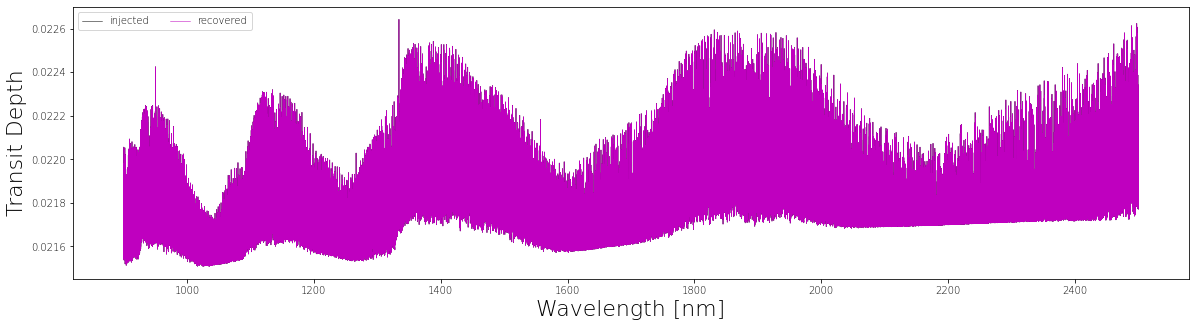

In [47]:
# Indicate below the name of the planet atmosphere template injected in the data
name_model       = "Model/Results/RpGL15A_HD189_onlyH2O-VMR3-T900.txt" 
name_wave         = "Model/Results/lambdasGL15A_HD189_onlyH2O-VMR3-T900.txt" 

W_mod,I_mod      = np.loadtxt(name_wave),np.loadtxt(name_model)
T_depth           = (I_mod/(1e5))**(2) / Rs**(2)
transit_depth              = (T_depth - T_depth1.mean())+ T_depth.mean()

W_mod_inj = W_mod1
transit_depth_inj = Td1

plt.figure(figsize=(20,5))
plt.plot(W_mod1,Td1,"-k",lw=.5,label="injected")
plt.plot(W_mod,transit_depth,"-m",lw=.5,label="recovered")
plt.ylabel("Transit Depth")
plt.xlabel("Wavelength [nm]")
plt.legend(ncol=2)
plt.show()

We now select the orders we will use to compute the correlation on. In practice, we advocate to select all available orders exhibiting absorption features to avoid any selection bias in the process (except in the order's spectrum exhibit significant telluric contamination or correlated noise). In our case, we compute the absolute difference between the injected planet template and the model used for the correlation. If this difference is larger than 2%, we discard the order. 

0 965.5044332166204 983.8165507668924
1 976.6417054157827 995.2187697526268
2 989.0299669050512 1008.2945029182512
3 1001.5613586409586 1022.0065662090464
4 1014.8663833224683 1036.6298737315258
5 1028.28454831894 1050.661399562598
6 1042.1372948193098 1065.1989859189875
7 1056.3730540179045 1078.7161743938045
8 1071.1325427685388 1094.0875790726202
9 1086.2134069796675 1109.6465437298928
10 1101.6475717886342 1124.2840854984984
11 1118.6003499546855 1143.1855739847956
12 1135.7930751891106 1160.053025624062
13 1151.484542113491 1178.038210953
14 1168.1045905487736 1197.698795151942
15 1187.047931038489 1216.6075963711096
16 1204.8565021469578 1236.3608879176718
17 1225.0236468935743 1256.533028351213
18 1243.9927191458044 1277.221647473631
19 1265.8124637028 1298.590849811825
20 1285.3216897375705 1320.3241826986643
21 1307.5946982658702 1343.056369054893
22 1333.240864996702 1343.6782406472917
23 1458.1329884771983 1498.5147480693156
24 1485.9371060345893 1527.9765634588928
25 1514.2

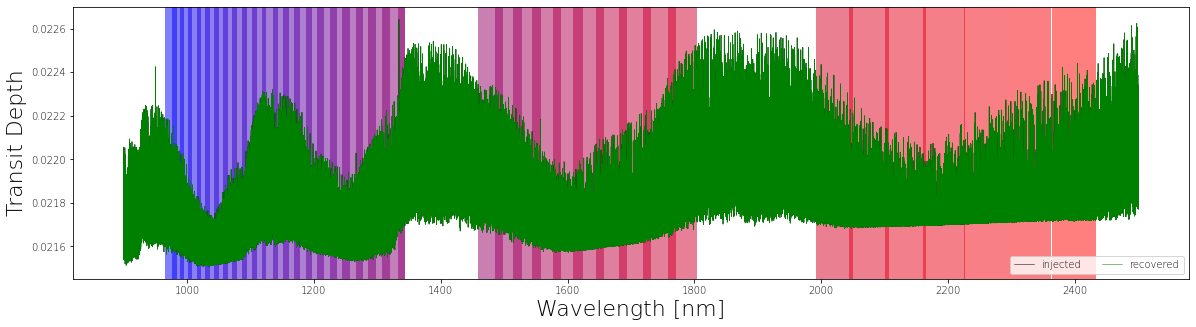

In [51]:
### Set the model to each relevant order
discard           = np.zeros(nord_fin)
list_ord_corr     = []
orders_corr       = []
index_orders_corr = []
Wmin_corr         = []
Wmax_corr         = []

for kk,O in enumerate(list_ord_pl_fin):
    #print(kk,O.W_red.min())
    Wmin,Wmax = 0.95*O.W_red.min(),1.05*O.W_red.max()
    indm      = np.where((W_mod>Wmin)&(W_mod<Wmax))[0]
    W_sel     = W_mod[indm]
    S         = np.std(transit_depth[indm])
    diff_transit=np.abs(np.mean(transit_depth[indm])-np.mean(transit_depth_inj[indm]))/np.mean(transit_depth_inj[indm])    
    #if np.min(W_sel) > 0.99*O.W_red.min() or np.max(W_sel) < 1.01*O.W_red.max() or S<1e-4:
    #if np.min(W_sel) > 0.99*O.W_red.min() or np.max(W_sel) < 1.01*O.W_red.max() or diff_transit>0.02: 
    if diff_transit>0.02:         
        print("Order",O.number," - Wm = ",wmean[kk],"nm - incomplete -- discarded (dispersion:",round(S,8),")") 
    else:
        ### If order selected, we save wavelength and 1-transit_depth in Order object's attributes
        O.Wm = W_sel
        O.Im = 1. - transit_depth[indm]
        list_ord_corr.append(O)
        orders_corr.append(O.number)
        index_orders_corr.append(kk)
        Wmin_corr.append(O.W_red.min())
        Wmax_corr.append(O.W_red.max())        


### Plot model and associated orders
plt.figure(figsize=(20,5))
plt.plot(W_mod_inj,transit_depth_inj,"-k",lw=.5,label="injected")
plt.plot(W_mod,transit_depth,"-g",lw=.5,label="recovered")
plt.ylabel("Transit Depth")
plt.xlabel("Wavelength [nm]")
plt.legend(ncol=2)
amount=len(orders_corr)-1
for kk,i in enumerate(orders_corr): 
    print(kk, Wmin_corr[kk], Wmax_corr[kk])
    c = [float(kk)/float(amount), 0.0, float(amount-kk)/float(amount)]
    plt.axvspan(Wmin_corr[kk], Wmax_corr[kk],color=c, alpha=0.5, lw=0) 



#### Main parameters of the grid for the correlation process

Select here the min/max values and the number of points for the (Kp,Vsys) grid. In this tutorial, we advocate to include no more than 20/30 steps for the Kp grid (for time purposes). 

In [53]:
### Parameters of the grid

### Semi-amplitude of the planet RV [km/s]
Kpmin = 50.0 #Jupiter
Kpmax = 250.0#Jupiter
#Kpmin = -50.0 #Neptune
#Kpmax = 150.0 #Neptune

Nkp   = 20 ### Size of the grid
Kp    = np.linspace(Kpmin,Kpmax,Nkp)

### Mid-transit planet RV [km/s]
Vmin = 0.0
Vmax =  60.0
Nv   = 61
Vsys = np.linspace(Vmin,Vmax,Nv)

### Order selection for computing the correlation (either manually or automatically)
#ord_sel = [50, 49, 48, 47, 46, 36, 35, 34]  #[70,58,47,46,32]  ### Manual seletion
ord_sel=orders_corr ### Automatic selection

#### Compute correlation maps

**Takes some time**

For each selected SPIRou order and for each sample of the (Kp,Vsys) grid:
- Interpolate the planet atmosphere spectrum.
- Build a sequence of planet atmosphere spectra by (1) shifting the planet atmosphere template according to the planet RV solution and weighting it by the transit window at each observation time, (2) bin each spectrum at the resolution of the SPIRou observations.
- Compute the average correlation coefficient between the observed and synthetic spectra

In [54]:
ind_sel = []
for kk,oo in enumerate(list_ord_corr):
    if oo.number in ord_sel: ind_sel.append(kk)
corr_pl = compute_correlation(np.array(list_ord_corr)[ind_sel],window,phase,Kp,Vsys)

NameError: name 'compute_correlation' is not defined

#### Post-analysis

- Compute maximum significance
- Compute error bars on Kp ad Vsys

We first convert the correlation map into a significance map by dividing it by the typical dispersion of the noise in the correlation map. The latter is simply computed by taking the standard deviation of the correlation map, on regions where the planetary signal is expected to be (mostly) absent (note that this is a simplistic approach and that, in practice, additional statistical tests can ensure a more robust estimation of the noise level, see [Birkby 2018](https://ui.adsabs.harvard.edu/abs/2018arXiv180604617B/abstract).). **Note:** Another method to estimate the typical noise level in the correlation map would be to compute the correlation map between the planet atmosphere template and a 2D matrix containing only noise (possibly amplified at the extremity of each order to account for the blaze function). The typical noise level is then simply given by the dispersion of the obtained correlation map.

We then fit a bivariate normal law to the significance map in the (Kp,Vsys) space and derive the best-fitting Kp and Vsys as well as the maximum significance. To compute the error bars on Kp and Vsys, we compute a densely-sampled bivariate normal law using the best-fitting parameters previously obtained. Then, starting from the maximum significance, we search the distance in the Kp space (resp. V_sys space) such that the significance decreases by 1 sigma (freezing the other parameter to its best estimate). Note that, if the grid is too small (and than no level lower than 1 sigma from the max is identified), we return the size of the grid as an error bar on the parameter as well as a warning message. In practice, we advocate to run the correlation maps on finely-sampled large grids in the (Kp,Vsys) space in order to ensure that the maximum of correlation is indeed global.

In [55]:
#### Compute statistics and plot the map

# Indicate regions to exclude when computing the NOISE level from the correlation map
Kp_lim    = [110,190]   # Exclude this Kp range we
Vsys_lim  = [-15.,15.]


### Compute significance map
snrmap_fin  = get_snrmap(np.array(orders_corr)[ind_sel],Kp,Vsys,corr_pl,Kp_lim,Vsys_lim)
sig_pl_fin  = np.sum(corr_pl[:,:,:]/snrmap_fin,axis=2)

### Get and display statistics
p_best,K_best,K_sup,K_inf,V_best,V_sup,V_inf = get_statistics(Vsys,Kp,sig_pl_fin)

NameError: name 'get_snrmap' is not defined

Plot the correlation maps:
- Color map showing the significance of the correlation with the planet template in the (Kp,Vsys) space
- 1D cuts at the injected values of Kp and Vsys
In each case, we indicate the injected values of Kp and Vsys by white dashed lines

In [ ]:
K_cut   = K_inj
V_cut   = V_inj
ind_v   = np.argmin(np.abs(Vsys-V_cut))
ind_k   = np.argmin(np.abs(Kp-K_cut))
sn_map  = sig_pl_fin
sn_cutx = sn_map[:,ind_v]
sn_cuty = sn_map[ind_k]

cmap = "gist_heat"
plot_correlation_map(Vsys,Kp,sn_map,V_inj,K_inj,cmap)

### Plot correlation + 1D cut
plot_correlation_map(Vsys,Kp,sn_map,V_inj,K_inj,cmap,sn_cutx,sn_cuty,20)